In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats

In [2]:
# os.chdir('phase1_occ_permutations')
# n_sub = len(os.listdir())
# permutations = []
# for file in os.listdir():
#     sub_acc = np.load(file)
#     sub_acc_mean = np.mean(sub_acc, axis = 0)
#     permutations.append(sub_acc_mean)

os.chdir('phase2_occ_permutations_f')
n_sub = len(os.listdir())
permutations_f = []
for file in os.listdir():
    sub_acc = np.load(file)
    sub_acc_mean = np.mean(sub_acc, axis = 0)
    permutations_f.append(sub_acc_mean)

os.chdir('../phase2_occ_permutations_inf')
permutations_inf = []
for file in os.listdir():
    sub_acc = np.load(file)
    sub_acc_mean = np.mean(sub_acc, axis = 0)
    permutations_inf.append(sub_acc_mean)

os.chdir('../')
print(f'number of subjects: {n_sub}')

number of subjects: 9


In [4]:
def find_inconsistent_lengths(list_of_arrays, list_name="your list"):
    """
    Checks a list of arrays for inconsistent lengths and prints a report.
    """
    if not list_of_arrays:
        print(f"'{list_name}' is empty.")
        return

    print(f"--- Checking list: {list_name} ---")
    
    # Get the length of the first array as the reference
    expected_len = len(list_of_arrays[0])
    print(f"Expecting all arrays to have length {expected_len}.")
    
    found_problem = False
    for i, arr in enumerate(list_of_arrays):
        if len(arr) != expected_len:
            print(f"  -> PROBLEM: Array at index {i} has length {len(arr)}.")
            found_problem = True
            
    if not found_problem:
        print("  ✓ All arrays have the same length. The problem might be something else.")

# --- Run the check on your lists ---
# find_inconsistent_lengths(permutations, "permutations")
find_inconsistent_lengths(permutations_f, "permutations_f")
find_inconsistent_lengths(permutations_inf, "permutations_inf")

--- Checking list: permutations_f ---
Expecting all arrays to have length 388.
  ✓ All arrays have the same length. The problem might be something else.
--- Checking list: permutations_inf ---
Expecting all arrays to have length 388.
  ✓ All arrays have the same length. The problem might be something else.


In [5]:
# mean = np.mean(permutations, axis = 0)
# std = np.std(permutations, axis = 0, ddof=1)
# sem = std / np.sqrt(n_sub)

mean_f = np.mean(permutations_f, axis = 0)
std_f = np.std(permutations_f, axis = 0, ddof=1)
sem_f = std_f / np.sqrt(n_sub)

mean_inf = np.mean(permutations_inf, axis = 0)
std_inf = np.std(permutations_inf, axis = 0, ddof=1)
sem_inf = std_inf / np.sqrt(n_sub)

In [6]:
# permutations = np.array(permutations)
permutations_f = np.array(permutations_f)
permutations_inf = np.array(permutations_inf)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


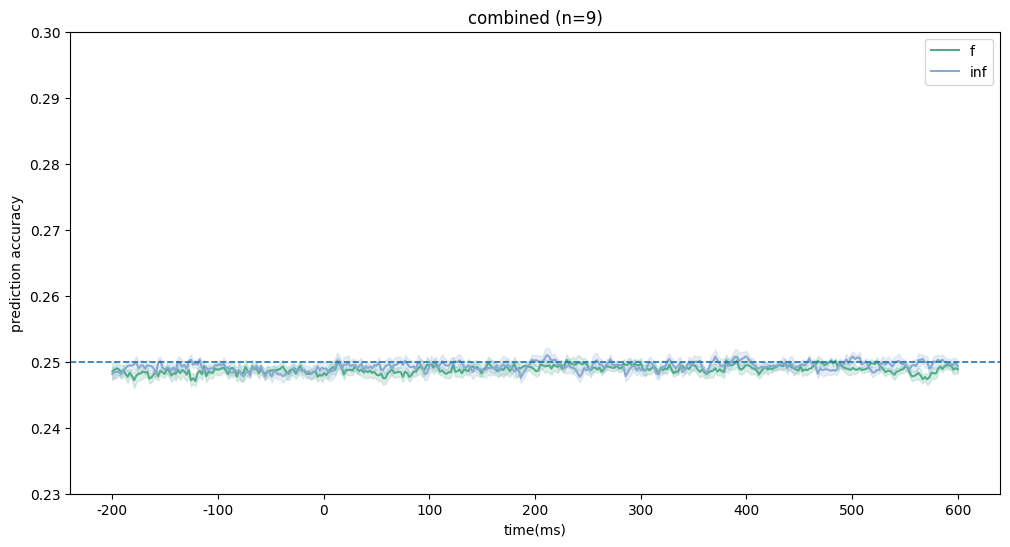

In [7]:
plt.figure(figsize=(12, 6))
x = np.arange(len(mean_f))
# plt.plot(x, mean, label = 'overall', color = '#C588BA')
# plt.fill_between(x, mean - sem, mean + sem, alpha=0.2, color = '#C588BA')

plt.plot(x, mean_f, label = 'f', color = '#52AC89')
plt.fill_between(x, mean_f - sem_f, mean_f + sem_f, alpha=0.2, color = '#52AC89')

plt.plot(x, mean_inf, label = 'inf', color = '#89A9D1')
plt.fill_between(x, mean_inf - sem_inf, mean_inf + sem_inf, alpha=0.2, color = '#89A9D1')

plt.axhline(0.25, linestyle='--',linewidth=1.2)

n_points = len(permutations_f[0])
tick_positions = np.linspace(0, n_points-1, 9)
tick_labels = np.linspace(-200, 600, 9).astype(int)
plt.xticks(tick_positions, tick_labels)

plt.ylim([0.23, 0.3])

plt.xlabel('time(ms)')
plt.ylabel('prediction accuracy')
plt.title(f'combined (n={n_sub})')

plt.legend()
plt.savefig('combined.eps', format='eps', bbox_inches='tight');